# WEEK 8 SVM journal

In this notebook I am testing Support Vector Machines on the RAVDESS audio features.

The assignment directions say the MiniLearn SVM is a simplified linear SVM, so I use my from-scratch linear SVM on a binary emotion problem first. Then I use sklearn's SVC for the full multiclass emotion problem with linear, RBF, and polynomial kernels.


In [10]:
# Week 8: SVM Classification for Speech Emotion Recognition
# Comparing MiniLearn SVM vs scikit-learn SVM with different kernels

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working dir:", os.getcwd())

from minilearn.helper import ezcols
from minilearn.preprocessing.Scaler import StandardScalerMM
from minilearn.preprocessing.test_train_splitfunc import train_test_split




Working dir: c:\Users\bradd\Project_CSE432-532\SER_Project


Loading up the feature dataset below

In [11]:
features = pd.read_csv("data/processed/features.csv")

print(features.shape)
features.head()

(2451, 496)


,filename,filepath,modality_number,modality,vocal_channel_number,vocal_channel,emotion_code,emotion,intensity_number,intensity,...,spec_centroid_min,spec_centroid_max,spec_bandwidth_mean,spec_bandwidth_std,spec_bandwidth_min,spec_bandwidth_max,spec_rolloff_mean,spec_rolloff_std,spec_rolloff_min,spec_rolloff_max
0,03-01-01-01-01-01-01.wav,data\Actor_01\03-01-01-01-01-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,14584.465982,5551.291828,1966.670942,0.000000,7941.362325,13285.735887,7873.634242,0.0000,20929.6875
1,03-01-01-01-01-02-01.wav,data\Actor_01\03-01-01-01-01-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,850.770544,12081.525541,5653.771579,1897.506371,2300.580933,8065.492390,13191.643371,7634.107567,960.9375,21140.6250
2,03-01-01-01-02-01-01.wav,data\Actor_01\03-01-01-01-02-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,12170.914340,5641.048020,2054.943735,0.000000,7938.570208,13279.137826,7981.393363,0.0000,21140.6250
3,03-01-01-01-02-02-01.wav,data\Actor_01\03-01-01-01-02-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,1001.254209,12108.222580,5802.315322,1915.796134,2313.602810,7918.679500,13272.074245,7570.671093,937.5000,21187.5000
4,03-01-02-01-01-01-01.wav,data\Actor_01\03-01-02-01-01-01-01.wav,3,audio-only,1,speech,2,calm,1,normal,...,0.000000,13533.883723,5518.637359,1916.039762,0.000000,8027.820710,12649.543486,7902.073642,0.0000,21585.9375


Down below I am picking the actual feature columns and the emotion column/target. Since this is a simple linear I am going to split it up into two different emotions to go up against. The most sane sounding is probably happy and sad

In [12]:
feature_cols = ezcols()

twoemotions =  features[features["emotion"].isin(["happy", "sad"])].copy()



X = twoemotions[feature_cols]
y = twoemotions["emotion"]

print(X.shape)
print(y.value_counts())

(752, 480)
emotion
happy    376
sad      376
Name: count, dtype: int64


My algorithm was not as good as the one used with SKLEARN. it has a higher train accuracy and test accuracy. However I am a little worried by the 100% train accuracy out of the SKLEAN model which means there probably was some type of over fitting.

In [13]:
from sklearn.svm import SVC
from minilearn.classifiers.SVM import SVMMM
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20, shuffle=True
)

scaler = StandardScalerMM()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

skimodel_linear = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
minilearnmodel_linear = SVMMM(C=1.0, learning=0.001, max_iters=1000)

skimodel_linear.fit(X_train_scaled, y_train)
minilearnmodel_linear.fit(X_train_scaled, y_train)

ski_pred = skimodel_linear.predict(X_test_scaled)
mini_pred = minilearnmodel_linear.predict(X_test_scaled)

print("MiniLearn train accuracy:", minilearnmodel_linear.score(X_train_scaled, y_train))
print("MiniLearn test accuracy:", minilearnmodel_linear.score(X_test_scaled, y_test))

print("Sklearn train accuracy:", skimodel_linear.score(X_train_scaled, y_train))
print("Sklearn test accuracy:", skimodel_linear.score(X_test_scaled, y_test))

(602, 480)
(150, 480)
MiniLearn train accuracy: 0.9169435215946844
MiniLearn test accuracy: 0.82
Sklearn train accuracy: 1.0
Sklearn test accuracy: 0.88


Sklearn Logistic Regression
Accuracy: 0.88
Precision macro: 0.8773619186046512
Recall macro: 0.8773619186046512
F1 macro: 0.8773619186046512
F1 weighted: 0.88


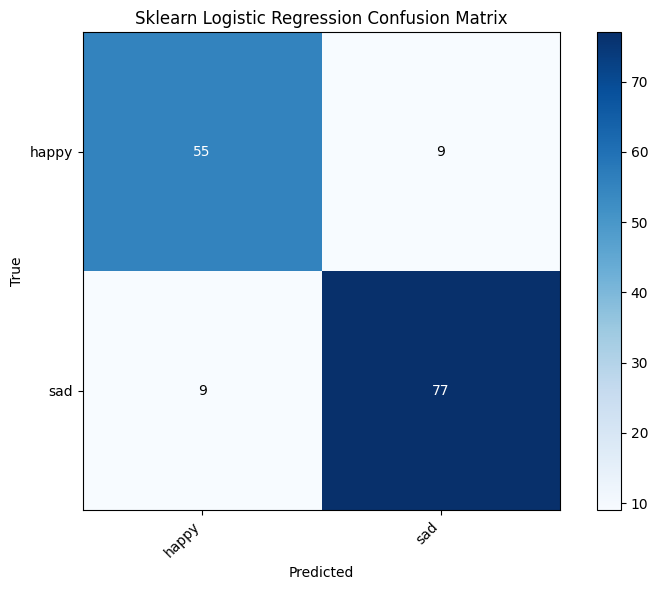

MiniLearn Logistic Regression
Accuracy: 0.82
Precision macro: 0.8221846646504181
Recall macro: 0.8290334302325582
F1 macro: 0.8193496587715777
F1 weighted: 0.8209393817743879


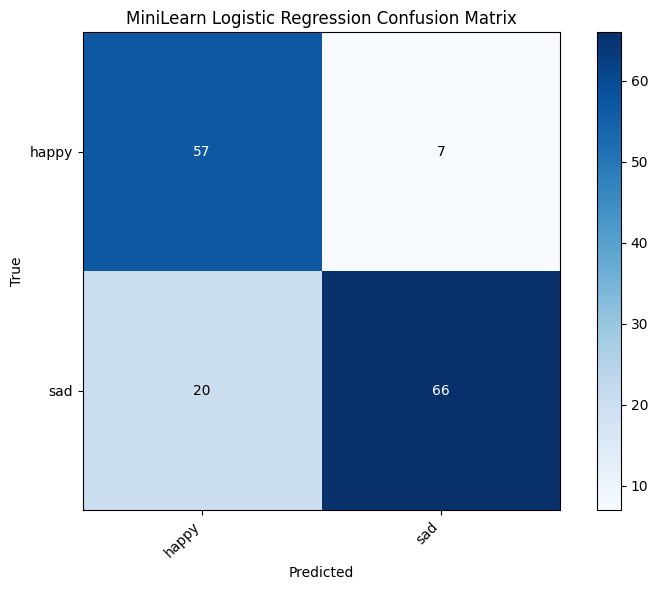

In [ ]:
from minilearn.metrics.metricss import (
    accuracy,
    confusion_matrix,
    precision,
    recall,
    f1_score,
    roc_auc,
    plot_confusion_matrix,
)

classes = y.unique()

classes = y.unique()
labels = classes.tolist()    # ← convert numpy array to Python list
class_names = labels

ski_pred = skimodel_linear.predict(X_test_scaled)
mini_pred = minilearnmodel_linear.predict(X_test_scaled)

for model_name, preds in [
    ("Sklearn linear SVM", ski_pred),
    ("MiniLearn linear SVM", mini_pred)
]:
    print("=" * 50)
    print(model_name)
    print("Accuracy:", accuracy(y_test, preds))
    print("Precision macro:", precision(y_test, preds, labels))
    print("Recall macro:", recall(y_test, preds, labels))
    print("F1 macro:", f1_score(y_test, preds, labels))
    print("F1 weighted:", f1_score(y_test, preds, labels, average="weighted"))
    cm = confusion_matrix(y_test, preds, labels)
    plot_confusion_matrix(cm, class_names, title=f"{model_name} Confusion Matrix")